Loading 404.wav...
Segmenting into non-overlapping 100ms windows...
Grouping frequencies into 22 Bark bands...
Quantizing and generating code-words...
Total 100ms frames analyzed: 86020
Exporting data to: 404_100ms_codewords.txt ...
Export complete!


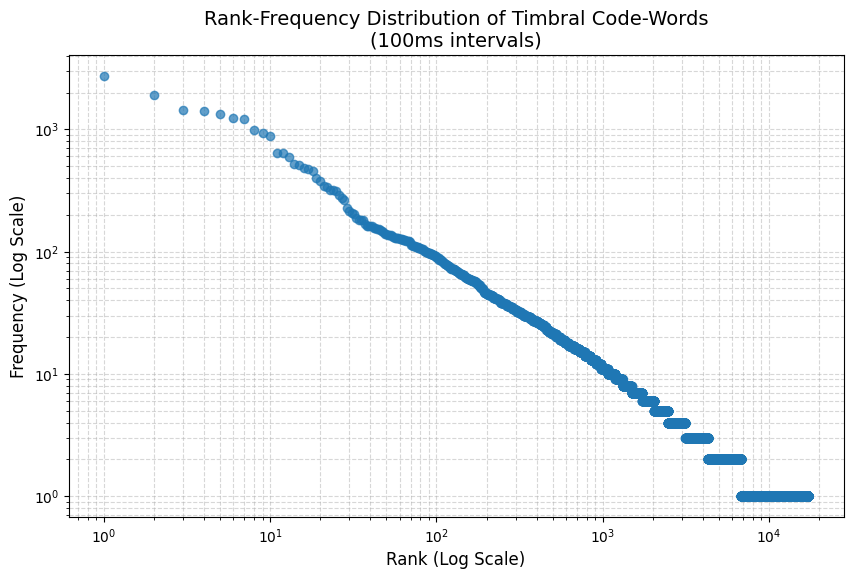

Number of unique code-words found: 17220


In [1]:
import librosa
import numpy as np
import os
import matplotlib.pyplot as plt
from collections import Counter

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
AUDIO_FILE = "404.wav"  # <-- CHANGE THIS TO YOUR UPLOADED FILE NAME
WINDOW_LENGTH_MS = 100

# The 22 Bark-band frequency edges defined in the paper
bark_edges = [0, 100, 200, 300, 400, 510, 630, 770, 920, 1080, 1270,
              1480, 1720, 2000, 2320, 2700, 3150, 3700, 4400, 5300,
              6400, 7700, 9500]

print(f"Loading {AUDIO_FILE}...")
# Load audio (we preserve original sample rate to accurately map frequencies)
y, sr = librosa.load(AUDIO_FILE, sr=None)

# ==========================================
# 2. FRAMING & POWER SPECTRUM
# ==========================================
win_length = int(sr * (WINDOW_LENGTH_MS / 1000.0))
hop_length = win_length

print(f"Segmenting into non-overlapping {WINDOW_LENGTH_MS}ms windows...")
stft_matrix = librosa.stft(y, n_fft=win_length, hop_length=hop_length, window='blackmanharris')

power_spectrum = np.abs(stft_matrix)**2
fft_freqs = librosa.fft_frequencies(sr=sr, n_fft=win_length)

# ==========================================
# 3. BARK-BAND GROUPING & NORMALIZATION
# ==========================================
print("Grouping frequencies into 22 Bark bands...")
num_windows = power_spectrum.shape[1]
bark_spectrogram = np.zeros((22, num_windows))

for i in range(22):
    lower_bound = bark_edges[i]
    upper_bound = bark_edges[i+1]
    idx = np.where((fft_freqs >= lower_bound) & (fft_freqs < upper_bound))[0]
    bark_spectrogram[i, :] = np.sum(power_spectrum[idx, :], axis=0)

window_energy_sums = np.sum(bark_spectrogram, axis=0) + 1e-10
norm_bark = bark_spectrogram / window_energy_sums

# ==========================================
# 4. QUANTIZATION & CODE-WORD GENERATION
# ==========================================
print("Quantizing and generating code-words...")
medians = np.median(norm_bark, axis=1, keepdims=True)
quantized_bark = (norm_bark >= medians).astype(int)

code_words = []
for j in range(num_windows):
    word = "".join(quantized_bark[:, j].astype(str))
    code_words.append(word)

# ==========================================
# 5. DATA EXPORT
# ==========================================
# Extract the base name of the audio file without the .mp3/.wav extension
base_name = os.path.splitext(AUDIO_FILE)[0]

# Create a filename that includes the window length for safe record keeping
output_filename = f"{base_name}_{WINDOW_LENGTH_MS}ms_codewords.txt"

print(f"Total {WINDOW_LENGTH_MS}ms frames analyzed: {num_windows}")
print(f"Exporting data to: {output_filename} ...")

# Write the code-words to a text file, one per line
with open(output_filename, 'w') as f:
    for word in code_words:
        f.write(word + "\n")

print("Export complete!")

# ==========================================
# 6. RANKING & PLOTTING
# ==========================================
# Count the frequency of use of each timbral code-word [cite: 137]
counts = Counter(code_words)
frequencies = sorted(list(counts.values()), reverse=True)
ranks = np.arange(1, len(frequencies) + 1)

# Plot rank-frequency distribution on a log-log scale [cite: 188]
plt.figure(figsize=(10, 6))
plt.loglog(ranks, frequencies, marker='o', linestyle='none', color='#1f77b4', alpha=0.7)
plt.xlabel("Rank (Log Scale)", fontsize=12)
plt.ylabel("Frequency (Log Scale)", fontsize=12)
plt.title(f"Rank-Frequency Distribution of Timbral Code-Words\n({WINDOW_LENGTH_MS}ms intervals)", fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

print(f"Number of unique code-words found: {len(ranks)}")

# ESTIMATING AI AUDIO LENGTH

In [ ]:
# Calculate exact audio hours from transcript
filename = "combined_transcripts.txt"
words_per_minute = 150  # Standard podcast speed

print(f"Counting words in {filename}...")

with open(filename, 'r', encoding='utf-8') as file:
    text = file.read()
    # .split() separates the text by spaces to count actual words
    word_count = len(text.split())

minutes = word_count / words_per_minute
hours = minutes / 60

print(f"Total Words: {word_count:,}")
print(f"Estimated Audio: {hours:.1f} hours (at {words_per_minute} wpm)")

Counting words in combined_transcripts.txt...
Total Words: 2,112,163
Estimated Audio: 234.7 hours (at 150 wpm)


# MICROSOFT TTS AUDIO GENERATION


In [ ]:
!pip install edge-tts asyncio

In [ ]:
import asyncio
import edge_tts
import os

from google.colab import drive
drive.mount('/content/drive')

# ==========================================
# 1. CONFIGURATION
# ==========================================
# We assume you uploaded the text file to Colab's default folder
INPUT_FILE = "494.txt"

# This saves the audio DIRECTLY into a new folder in your Google Drive!
OUTPUT_DIR = "/content/drive/MyDrive/Podcast_Audio_Files"

VOICE = "en-US-EricNeural"
LINES_PER_CHUNK = 5000

# ==========================================
# 2. GENERATION LOGIC
# ==========================================
async def generate_audio():
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)

    print(f"Reading {INPUT_FILE}...")
    with open(INPUT_FILE, "r", encoding="utf-8") as file:
        lines = file.readlines()

    lines = [line.strip() for line in lines if line.strip()]

    total_chunks = (len(lines) // LINES_PER_CHUNK) + 1
    print(f"Total lines of dialogue: {len(lines)}.")
    print(f"Splitting into {total_chunks} separate MP3 files...")

    for i in range(0, len(lines), LINES_PER_CHUNK):
        chunk_num = (i // LINES_PER_CHUNK) + 1
        chunk_text = " ".join(lines[i:i + LINES_PER_CHUNK])

        output_file = os.path.join(OUTPUT_DIR, f"podcast_part_{chunk_num:04d}.mp3")

        # Skip this file if we already generated it (helps if Colab crashes and you need to restart!)
        if os.path.exists(output_file):
            print(f"Chunk {chunk_num} already exists. Skipping...")
            continue

        print(f"Generating {output_file} ({chunk_num}/{total_chunks})...")

        try:
            communicate = edge_tts.Communicate(chunk_text, VOICE)
            await communicate.save(output_file)
            await asyncio.sleep(3) # Crucial pause to avoid being blocked

        except Exception as e:
            print(f"Error on chunk {chunk_num}. Skipping. Error details: {e}")

    print("\nSuccess! All audio generation is complete.")

# ==========================================
# 3. RUN THE SCRIPT (Colab Specific)
# ==========================================
# Colab requires us to await the function directly instead of using asyncio.run()
await generate_audio()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading 494.txt...
Total lines of dialogue: 3863.
Splitting into 1 separate MP3 files...
Generating /content/drive/MyDrive/Podcast_Audio_Files/podcast_part_0001.mp3 (1/1)...

Success! All audio generation is complete.
